# Multi-Patch Grid Connections in Springsteel.jl

This notebook demonstrates the multi-patch grid connection system, which links separate `SpringsteelGrid` objects through spectral coefficient-space coupling. This enables:

- **Patch chains** with resolution changes at interfaces (2:1 or 1:1 ratio)
- **Embedded patches** where fine grids sit inside coarser grids
- **Domain decomposition** via 1:1 same-resolution patching

The coupling uses an exact 3x3 matrix derived from cubic B-spline basis function properties. At each interface, the coarser (primary) patch has R0 (free) boundary conditions, and the finer (secondary) patch receives R3X boundary data.

## Key types and functions

| Name | Purpose |
|------|---------|
| `PatchInterface` | Describes a directional connection between two patches |
| `MultiPatchGrid` | Container with topological transform ordering |
| `update_interface!` | Transfers coefficients from primary to secondary |
| `multiGridTransform!` | Coupled inverse transform across all patches |
| `PatchChain` | Build a chain of grids connected end-to-end (auto-detects primary/secondary) |
| `PatchEmbedded` | Build nested grids from outermost to innermost |

In [1]:
using Springsteel
using CairoMakie
using LinearAlgebra

[ Info: Precompiling Springsteel [66b52f22-0fad-4358-9559-2105d4560aaf] (cache misses: include_dependency fsize change (2), wrong dep version loaded (6), mismatched flags (8))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Example 1: 3-Patch Chain with Linear Function

A simple chain has three patches connected end-to-end: coarse — fine — coarse. `PatchChain` auto-detects that the coarser grids are primary at each interface. A linear function is reproduced to machine precision.

In [2]:
# Define test function
f_linear(x) = 3x + 5

# Primary left: [0, 10], 10 coarse cells (DX = 1.0)
gp_left = SpringsteelGridParameters(
    geometry="R", iMin=0.0, iMax=10.0, num_cells=10,
    BCL=Dict("u" => CubicBSpline.R0),
    BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

# Secondary: [10, 20], 20 fine cells (DX = 0.5, 2:1 ratio)
gp_sec = SpringsteelGridParameters(
    geometry="R", iMin=10.0, iMax=20.0, num_cells=20,
    BCL=Dict("u" => CubicBSpline.R3X),
    BCR=Dict("u" => CubicBSpline.R3X),
    vars=Dict("u" => 1))

# Primary right: [20, 30], 10 coarse cells (DX = 1.0)
gp_right = SpringsteelGridParameters(
    geometry="R", iMin=20.0, iMax=30.0, num_cells=10,
    BCL=Dict("u" => CubicBSpline.R0),
    BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

g_left = createGrid(gp_left)
g_sec  = createGrid(gp_sec)
g_right = createGrid(gp_right)

# Fill physical values and forward transform
for (g, pts) in [(g_left, getGridpoints(g_left)),
                  (g_sec, getGridpoints(g_sec)),
                  (g_right, getGridpoints(g_right))]
    for i in eachindex(pts)
        g.physical[i, 1, 1] = f_linear(pts[i])
    end
    spectralTransform!(g)
end

# PatchChain auto-detects coarser grid as primary at each interface
mpg = PatchChain([g_left, g_sec, g_right])
multiGridTransform!(mpg)

println("Chain created with $(length(mpg.patches)) patches and $(length(mpg.interfaces)) interfaces")
println("Transform order (layers): $(mpg.transform_order)")

Chain created with 3 patches and 2 interfaces
Transform order (layers): [[1, 3], [2]]


Max error — left: 1.0658141036401503e-14, center: 4.263256414560601e-14, right: 4.263256414560601e-14


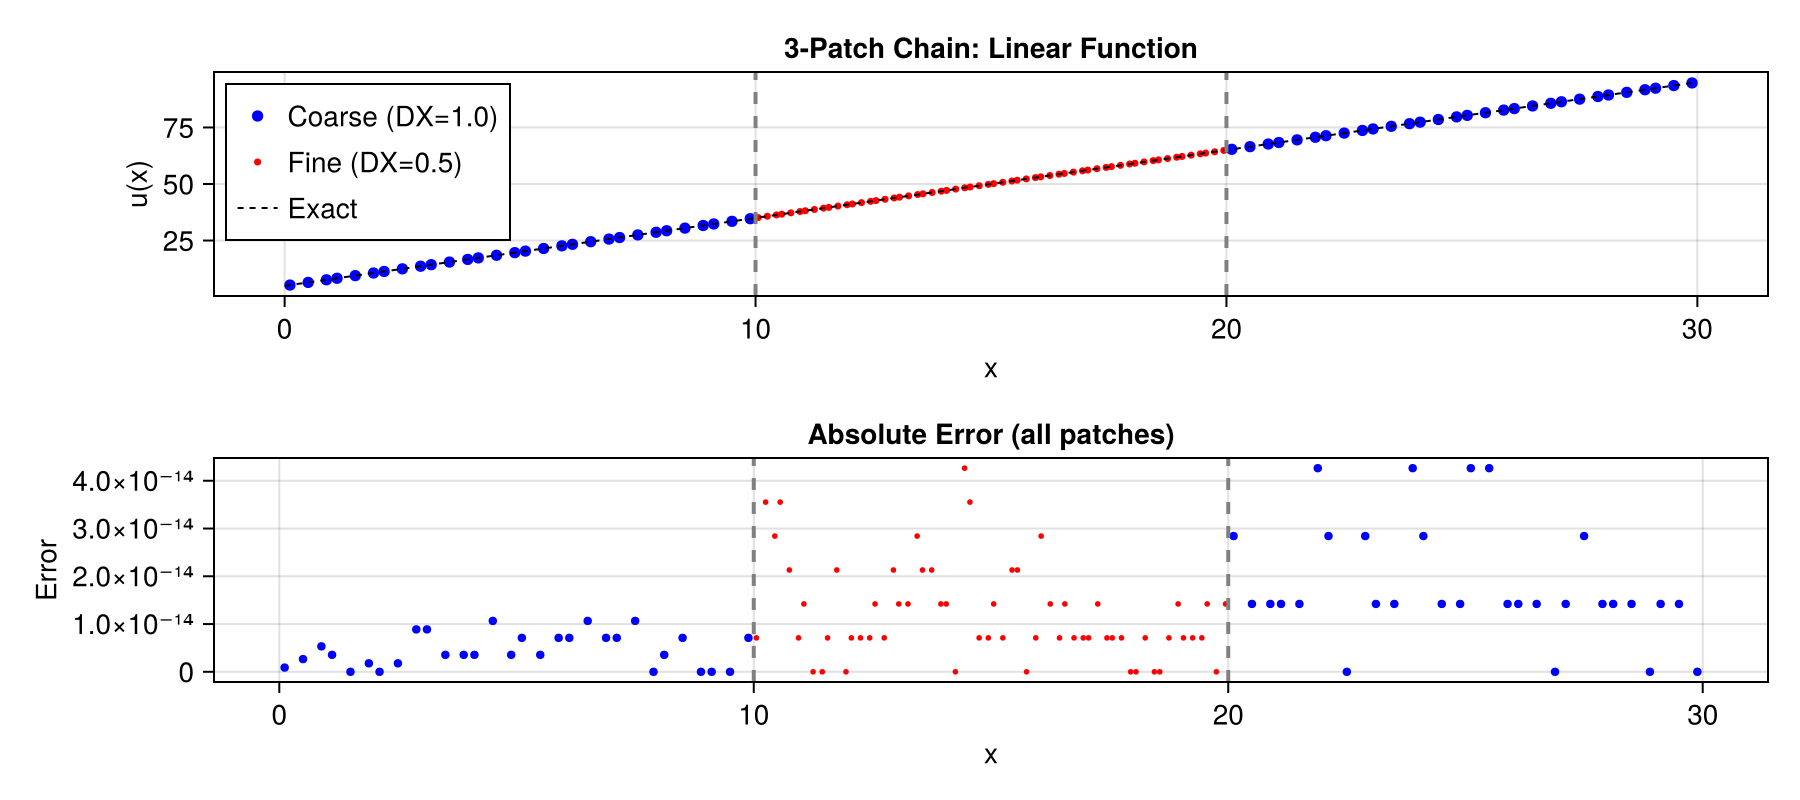

In [3]:
# Visualize the 3-patch chain
fig = Figure(size=(900, 400))

ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="u(x)", title="3-Patch Chain: Linear Function")

pts_l = getGridpoints(g_left)
pts_s = getGridpoints(g_sec)
pts_r = getGridpoints(g_right)

scatter!(ax1, pts_l, g_left.physical[:, 1, 1]; color=:blue, markersize=8, label="Coarse (DX=1.0)")
scatter!(ax1, pts_s, g_sec.physical[:, 1, 1]; color=:red, markersize=5, label="Fine (DX=0.5)")
scatter!(ax1, pts_r, g_right.physical[:, 1, 1]; color=:blue, markersize=8)

x_ref = range(0, 30, length=200)
lines!(ax1, collect(x_ref), f_linear.(x_ref); color=:black, linewidth=1, linestyle=:dash, label="Exact")
vlines!(ax1, [10.0, 20.0]; color=:gray, linewidth=2, linestyle=:dash)
axislegend(ax1; position=:lt)

# Error plot
ax2 = Axis(fig[2, 1]; xlabel="x", ylabel="Error", title="Absolute Error (all patches)")
err_l = abs.(g_left.physical[:, 1, 1] .- f_linear.(pts_l))
err_s = abs.(g_sec.physical[:, 1, 1] .- f_linear.(pts_s))
err_r = abs.(g_right.physical[:, 1, 1] .- f_linear.(pts_r))

scatter!(ax2, pts_l, err_l; color=:blue, markersize=6)
scatter!(ax2, pts_s, err_s; color=:red, markersize=4)
scatter!(ax2, pts_r, err_r; color=:blue, markersize=6)
vlines!(ax2, [10.0, 20.0]; color=:gray, linewidth=2, linestyle=:dash)

println("Max error — left: $(maximum(err_l)), center: $(maximum(err_s)), right: $(maximum(err_r))")

fig

## Example 2: Effect of Smoothing (l_q) on Coupling Accuracy

The `l_q` parameter controls the smoothing penalty in the SA variational solve. The coupling matrix maps **unsmoothed** B-spline amplitudes exactly, so any smoothing modifies the coefficients and introduces error through the interface.

Here we compare a sinusoidal function with `l_q = 0` (no smoothing) vs `l_q = 2` (default).

In [4]:
f_sin(x) = sin(2π * x / 30.0) + 1.0

function run_chain_1d(f, nc_primary, nc_secondary; l_q_val=2.0)
    lq = Dict("u" => l_q_val)
    gp1 = SpringsteelGridParameters(
        geometry="R", iMin=0.0, iMax=10.0, num_cells=nc_primary, l_q=lq,
        BCL=Dict("u" => CubicBSpline.R0), BCR=Dict("u" => CubicBSpline.R0),
        vars=Dict("u" => 1))
    gp2 = SpringsteelGridParameters(
        geometry="R", iMin=10.0, iMax=20.0, num_cells=nc_secondary, l_q=lq,
        BCL=Dict("u" => CubicBSpline.R3X), BCR=Dict("u" => CubicBSpline.R3X),
        vars=Dict("u" => 1))
    gp3 = SpringsteelGridParameters(
        geometry="R", iMin=20.0, iMax=30.0, num_cells=nc_primary, l_q=lq,
        BCL=Dict("u" => CubicBSpline.R0), BCR=Dict("u" => CubicBSpline.R0),
        vars=Dict("u" => 1))

    g1 = createGrid(gp1); g2 = createGrid(gp2); g3 = createGrid(gp3)
    for (g, pts) in [(g1, getGridpoints(g1)), (g2, getGridpoints(g2)), (g3, getGridpoints(g3))]
        for i in eachindex(pts); g.physical[i, 1, 1] = f(pts[i]); end
        spectralTransform!(g)
    end

    mpg = PatchChain([g1, g2, g3])
    multiGridTransform!(mpg)
    return g1, g2, g3
end

# Run with l_q = 0 and l_q = 2
g1_lq0, g2_lq0, g3_lq0 = run_chain_1d(f_sin, 10, 20; l_q_val=0.0)
g1_lq2, g2_lq2, g3_lq2 = run_chain_1d(f_sin, 10, 20; l_q_val=2.0)

println("l_q = 0 and l_q = 2 runs complete")

l_q = 0 and l_q = 2 runs complete


l_q=0 secondary max error: 1.3543692724521383e-5
l_q=2 secondary max error: 0.0004339639689342478


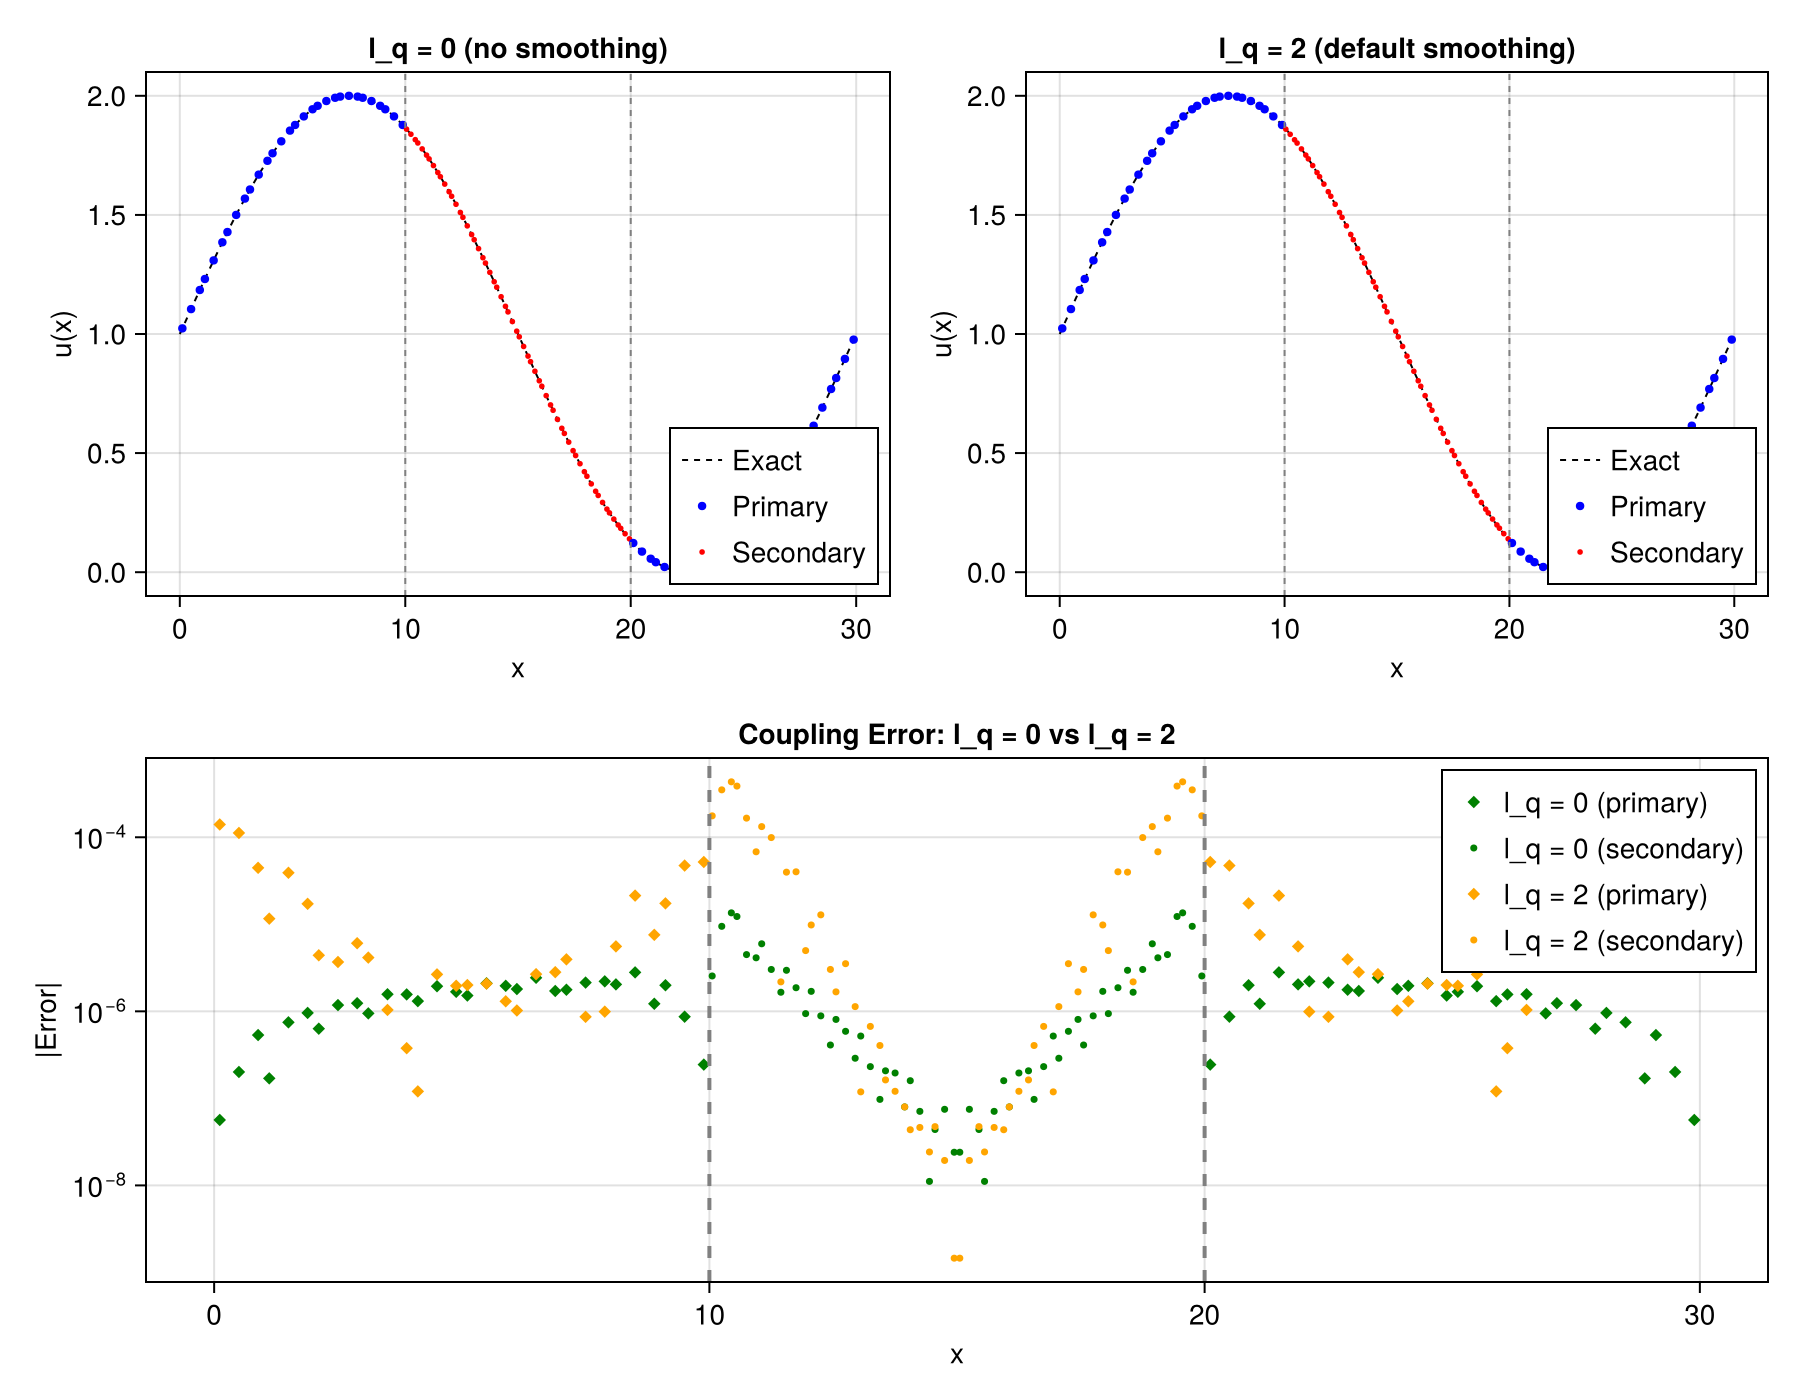

In [5]:
# Compare l_q = 0 vs l_q = 2 for sinusoidal function
fig = Figure(size=(900, 700))

# --- Top row: reconstructed fields ---
ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="u(x)", title="l_q = 0 (no smoothing)")
ax2 = Axis(fig[1, 2]; xlabel="x", ylabel="u(x)", title="l_q = 2 (default smoothing)")

x_ref = collect(range(0, 30, length=300))
for (ax, g1, g2, g3) in [(ax1, g1_lq0, g2_lq0, g3_lq0),
                           (ax2, g1_lq2, g2_lq2, g3_lq2)]
    lines!(ax, x_ref, f_sin.(x_ref); color=:black, linewidth=1, linestyle=:dash, label="Exact")
    scatter!(ax, getGridpoints(g1), g1.physical[:, 1, 1]; color=:blue, markersize=6, label="Primary")
    scatter!(ax, getGridpoints(g2), g2.physical[:, 1, 1]; color=:red, markersize=4, label="Secondary")
    scatter!(ax, getGridpoints(g3), g3.physical[:, 1, 1]; color=:blue, markersize=6)
    vlines!(ax, [10.0, 20.0]; color=:gray, linewidth=1, linestyle=:dash)
    axislegend(ax; position=:rb)
end
linkyaxes!(ax1, ax2)

# --- Bottom row: error comparison ---
ax3 = Axis(fig[2, 1:2]; xlabel="x", ylabel="|Error|",
           title="Coupling Error: l_q = 0 vs l_q = 2", yscale=log10)

for (g1, g2, g3, lq_label, col) in [
    (g1_lq0, g2_lq0, g3_lq0, "l_q = 0", :green),
    (g1_lq2, g2_lq2, g3_lq2, "l_q = 2", :orange)]

    for (g, is_sec) in [(g1, false), (g2, true), (g3, false)]
        pts = getGridpoints(g)
        err = abs.(g.physical[:, 1, 1] .- f_sin.(pts))
        err[err .< 1e-16] .= 1e-16  # floor for log scale
        marker = is_sec ? :circle : :diamond
        ms = is_sec ? 5 : 7
        lbl = is_sec ? "$lq_label (secondary)" : (g === g1 ? "$lq_label (primary)" : nothing)
        scatter!(ax3, pts, err; color=col, markersize=ms, marker=marker, label=lbl)
    end
end

vlines!(ax3, [10.0, 20.0]; color=:gray, linewidth=2, linestyle=:dash)
axislegend(ax3; position=:rt)

# Print summary
for (label, g2) in [("l_q=0", g2_lq0), ("l_q=2", g2_lq2)]
    pts = getGridpoints(g2)
    max_err = maximum(abs.(g2.physical[:, 1, 1] .- f_sin.(pts)))
    println("$label secondary max error: $max_err")
end

fig

## Example 3: Cubic Polynomial — l_q = 0 vs l_q = 2

Cubic polynomials are within the reproduction range of cubic B-splines. With `l_q = 0`, the coupling is exact to machine precision. With `l_q = 2`, the smoothing penalty modifies the spectral coefficients, amplifying error through the interface by a constant factor (~50-70x the single-grid error).

Cubic l_q=0: secondary max error = 4.547473508864641e-11
Cubic l_q=2: secondary max error = 0.6702760390289768


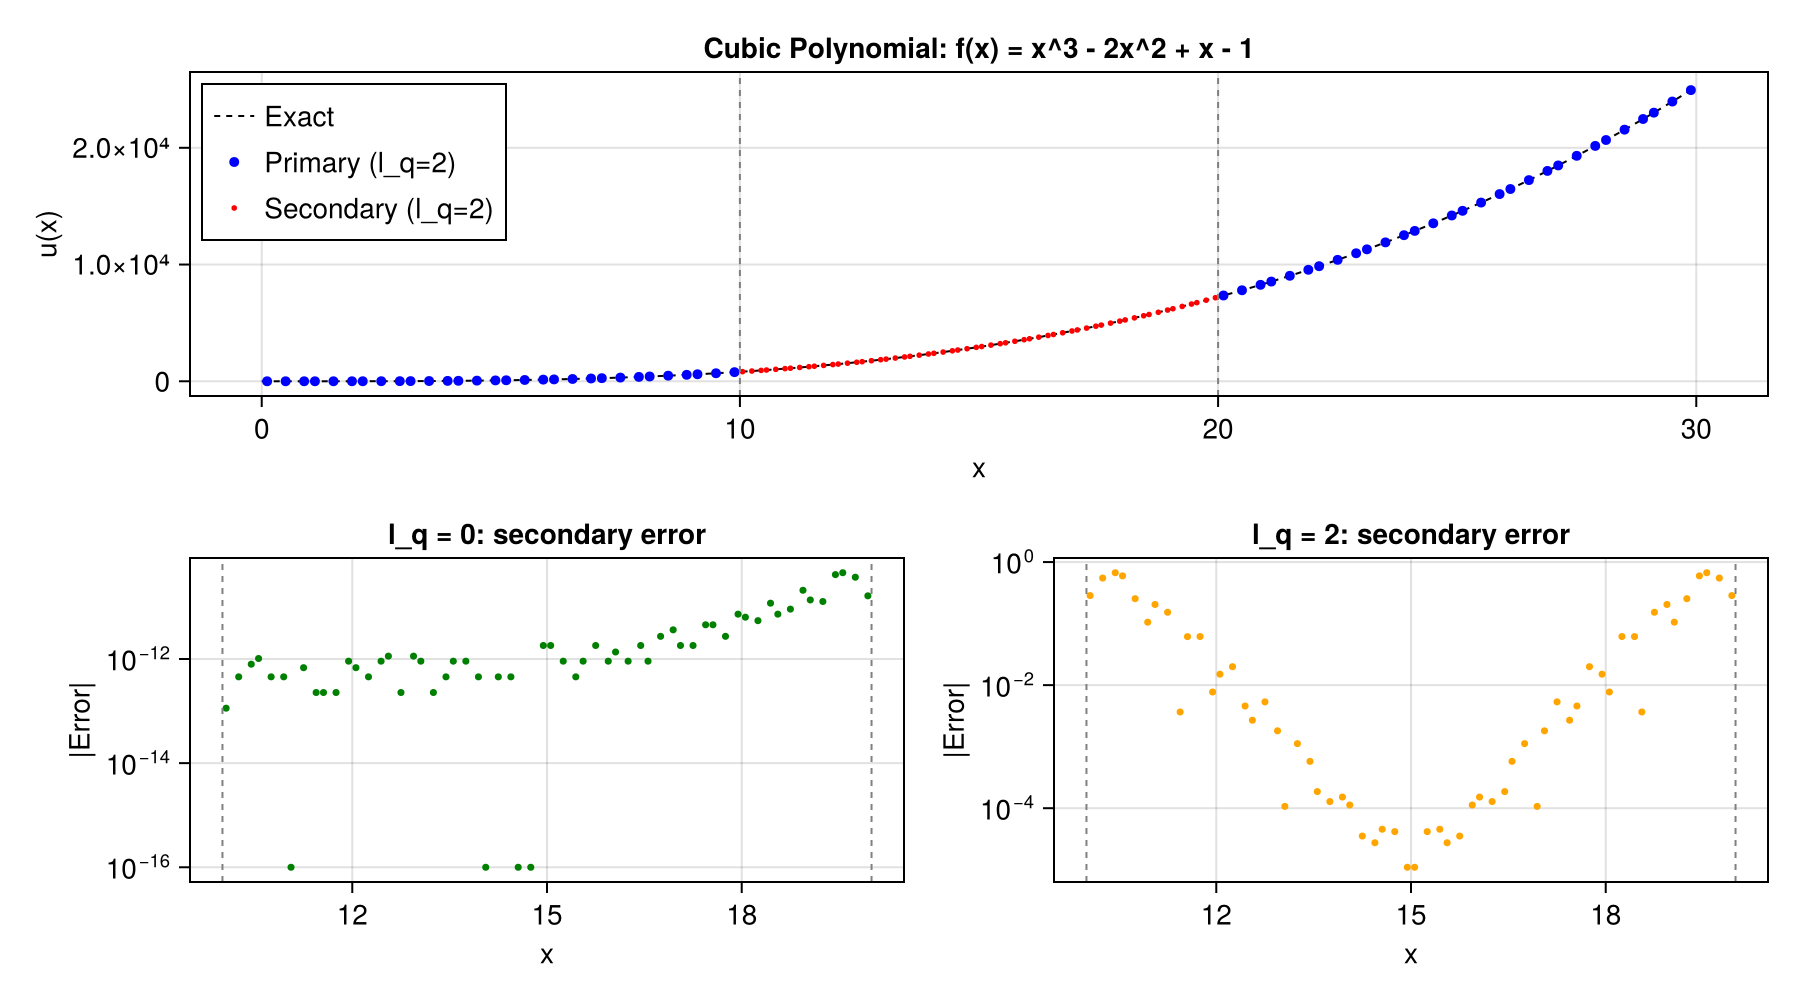

In [6]:
f_cubic(x) = x^3 - 2x^2 + x - 1

g1_c0, g2_c0, g3_c0 = run_chain_1d(f_cubic, 10, 20; l_q_val=0.0)
g1_c2, g2_c2, g3_c2 = run_chain_1d(f_cubic, 10, 20; l_q_val=2.0)

fig = Figure(size=(900, 500))

# Field values
x_ref = collect(range(0, 30, length=300))
ax1 = Axis(fig[1, 1:2]; xlabel="x", ylabel="u(x)", title="Cubic Polynomial: f(x) = x^3 - 2x^2 + x - 1")
lines!(ax1, x_ref, f_cubic.(x_ref); color=:black, linewidth=1, linestyle=:dash, label="Exact")
scatter!(ax1, getGridpoints(g1_c2), g1_c2.physical[:, 1, 1]; color=:blue, markersize=7, label="Primary (l_q=2)")
scatter!(ax1, getGridpoints(g2_c2), g2_c2.physical[:, 1, 1]; color=:red, markersize=4, label="Secondary (l_q=2)")
scatter!(ax1, getGridpoints(g3_c2), g3_c2.physical[:, 1, 1]; color=:blue, markersize=7)
vlines!(ax1, [10.0, 20.0]; color=:gray, linewidth=1, linestyle=:dash)
axislegend(ax1; position=:lt)

# Error comparison
ax2 = Axis(fig[2, 1]; xlabel="x", ylabel="|Error|", title="l_q = 0: secondary error", yscale=log10)
ax3 = Axis(fig[2, 2]; xlabel="x", ylabel="|Error|", title="l_q = 2: secondary error", yscale=log10)

for (ax, g2, col, lq) in [(ax2, g2_c0, :green, 0), (ax3, g2_c2, :orange, 2)]
    pts = getGridpoints(g2)
    err = abs.(g2.physical[:, 1, 1] .- f_cubic.(pts))
    err[err .< 1e-16] .= 1e-16
    scatter!(ax, pts, err; color=col, markersize=5)
    vlines!(ax, [10.0, 20.0]; color=:gray, linewidth=1, linestyle=:dash)
    max_err = maximum(abs.(g2.physical[:, 1, 1] .- f_cubic.(pts)))
    println("Cubic l_q=$lq: secondary max error = $max_err")
end

fig

## Example 4: Embedded Patches

`PatchEmbedded` places fine grids inside coarser grids. The outer (primary) grid covers the full domain, and inner grids receive R3X boundary data from the grid they are embedded in.

Coarse max error: 5.3917380244628e-5
Fine max error:   3.833251187707054e-5


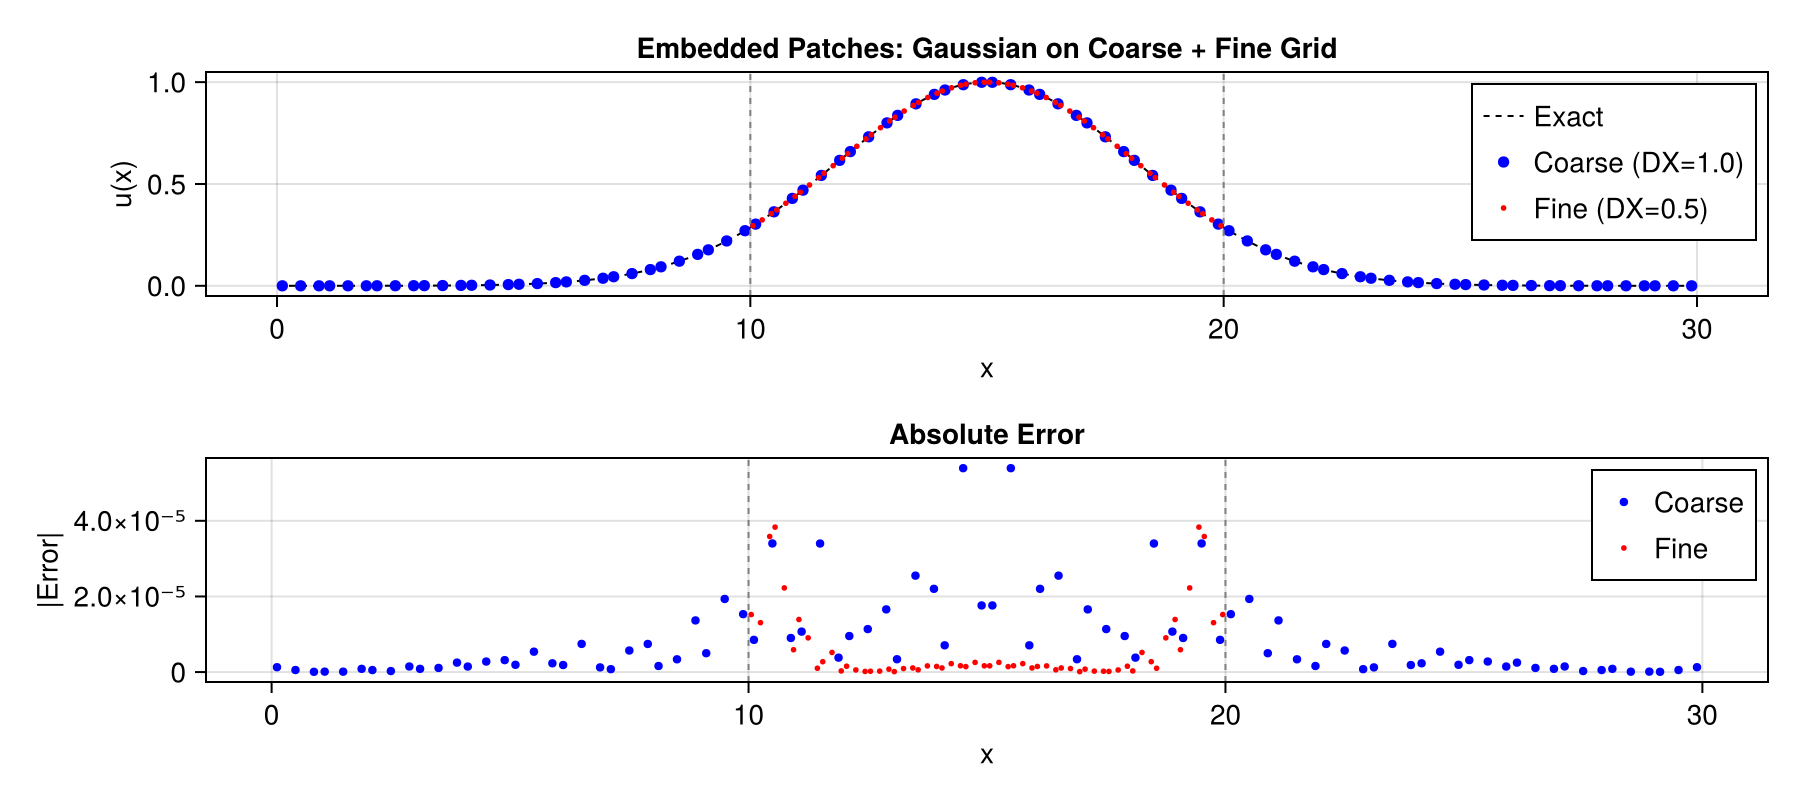

In [7]:
f_gauss(x) = exp(-(x - 15)^2 / 20.0)

# Coarse primary: full domain [0, 30], 30 cells (DX = 1.0)
gp_coarse = SpringsteelGridParameters(
    geometry="R", iMin=0.0, iMax=30.0, num_cells=30,
    BCL=Dict("u" => CubicBSpline.R0),
    BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

# Fine secondary: interior [10, 20], 20 cells (DX = 0.5, 2:1 ratio)
gp_fine = SpringsteelGridParameters(
    geometry="R", iMin=10.0, iMax=20.0, num_cells=20,
    BCL=Dict("u" => CubicBSpline.R3X),
    BCR=Dict("u" => CubicBSpline.R3X),
    vars=Dict("u" => 1))

g_coarse = createGrid(gp_coarse)
g_fine = createGrid(gp_fine)

for (g, pts) in [(g_coarse, getGridpoints(g_coarse)), (g_fine, getGridpoints(g_fine))]
    for i in eachindex(pts)
        g.physical[i, 1, 1] = f_gauss(pts[i])
    end
    spectralTransform!(g)
end

# PatchEmbedded: outermost to innermost
mpg_emb = PatchEmbedded([g_coarse, g_fine])
multiGridTransform!(mpg_emb)

# Visualize
fig = Figure(size=(900, 400))
x_ref = collect(range(0, 30, length=300))

ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="u(x)", title="Embedded Patches: Gaussian on Coarse + Fine Grid")
lines!(ax1, x_ref, f_gauss.(x_ref); color=:black, linewidth=1, linestyle=:dash, label="Exact")
scatter!(ax1, getGridpoints(g_coarse), g_coarse.physical[:, 1, 1];
         color=:blue, markersize=8, label="Coarse (DX=1.0)")
scatter!(ax1, getGridpoints(g_fine), g_fine.physical[:, 1, 1];
         color=:red, markersize=4, label="Fine (DX=0.5)")
vlines!(ax1, [10.0, 20.0]; color=:gray, linewidth=1, linestyle=:dash)
axislegend(ax1; position=:rt)

# Error
ax2 = Axis(fig[2, 1]; xlabel="x", ylabel="|Error|", title="Absolute Error")
pts_c = getGridpoints(g_coarse)
pts_f = getGridpoints(g_fine)
err_c = abs.(g_coarse.physical[:, 1, 1] .- f_gauss.(pts_c))
err_f = abs.(g_fine.physical[:, 1, 1] .- f_gauss.(pts_f))
scatter!(ax2, pts_c, err_c; color=:blue, markersize=6, label="Coarse")
scatter!(ax2, pts_f, err_f; color=:red, markersize=4, label="Fine")
vlines!(ax2, [10.0, 20.0]; color=:gray, linewidth=1, linestyle=:dash)
axislegend(ax2; position=:rt)

println("Coarse max error: $(maximum(err_c))")
println("Fine max error:   $(maximum(err_f))")

fig

## Example 5: 2D Patch Chain (RR Grid)

Multi-patch connections work on 2D spline-spline (RR) grids. The interface transfer is performed independently for each j-spectral mode. Here we connect two RR grids along the i-dimension using a direct `PatchInterface`.

In [8]:
# 2D function: Gaussian blob centered at (12, 2.5)
f_2d(x, y) = exp(-((x - 12)^2 + (y - 2.5)^2) / 8.0)

nc_j = 8
jDim = nc_j * 3
b_jDim = nc_j + 3

# Primary left: [0, 10] x [0, 5], 10 i-cells (DX = 1.0)
gp_2d_left = SpringsteelGridParameters(
    geometry="RR", iMin=0.0, iMax=10.0, num_cells=10,
    jMin=0.0, jMax=5.0, jDim=jDim, b_jDim=b_jDim,
    BCL=Dict("u" => CubicBSpline.R0), BCR=Dict("u" => CubicBSpline.R0),
    BCU=Dict("u" => CubicBSpline.R0), BCD=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

# Secondary: [10, 15] x [0, 5], 10 i-cells (DX = 0.5, 2:1 ratio)
gp_2d_sec = SpringsteelGridParameters(
    geometry="RR", iMin=10.0, iMax=15.0, num_cells=10,
    jMin=0.0, jMax=5.0, jDim=jDim, b_jDim=b_jDim,
    BCL=Dict("u" => CubicBSpline.R3X), BCR=Dict("u" => CubicBSpline.R0),
    BCU=Dict("u" => CubicBSpline.R0), BCD=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

g2d_left = createGrid(gp_2d_left)
g2d_sec = createGrid(gp_2d_sec)

# Fill physical values
for (g, gp) in [(g2d_left, gp_2d_left), (g2d_sec, gp_2d_sec)]
    iDim = gp.iDim
    pts_i = g.ibasis.data[1, 1].mishPoints
    pts_j = g.jbasis.data[1, 1].mishPoints
    for r in 1:iDim
        for l in 1:jDim
            idx = (r - 1) * jDim + l
            g.physical[idx, 1, 1] = f_2d(pts_i[r], pts_j[l])
        end
    end
    spectralTransform!(g)
end

# Connect and transform
iface_2d = PatchInterface(g2d_left, g2d_sec, :right, :left, :i)
gridTransform!(g2d_left)
update_interface!(iface_2d)
gridTransform!(g2d_sec)

println("2D interface transfer complete")

2D interface transfer complete


Primary left max error: 0.0013075729642457734
Secondary max error:    0.012324370527622253


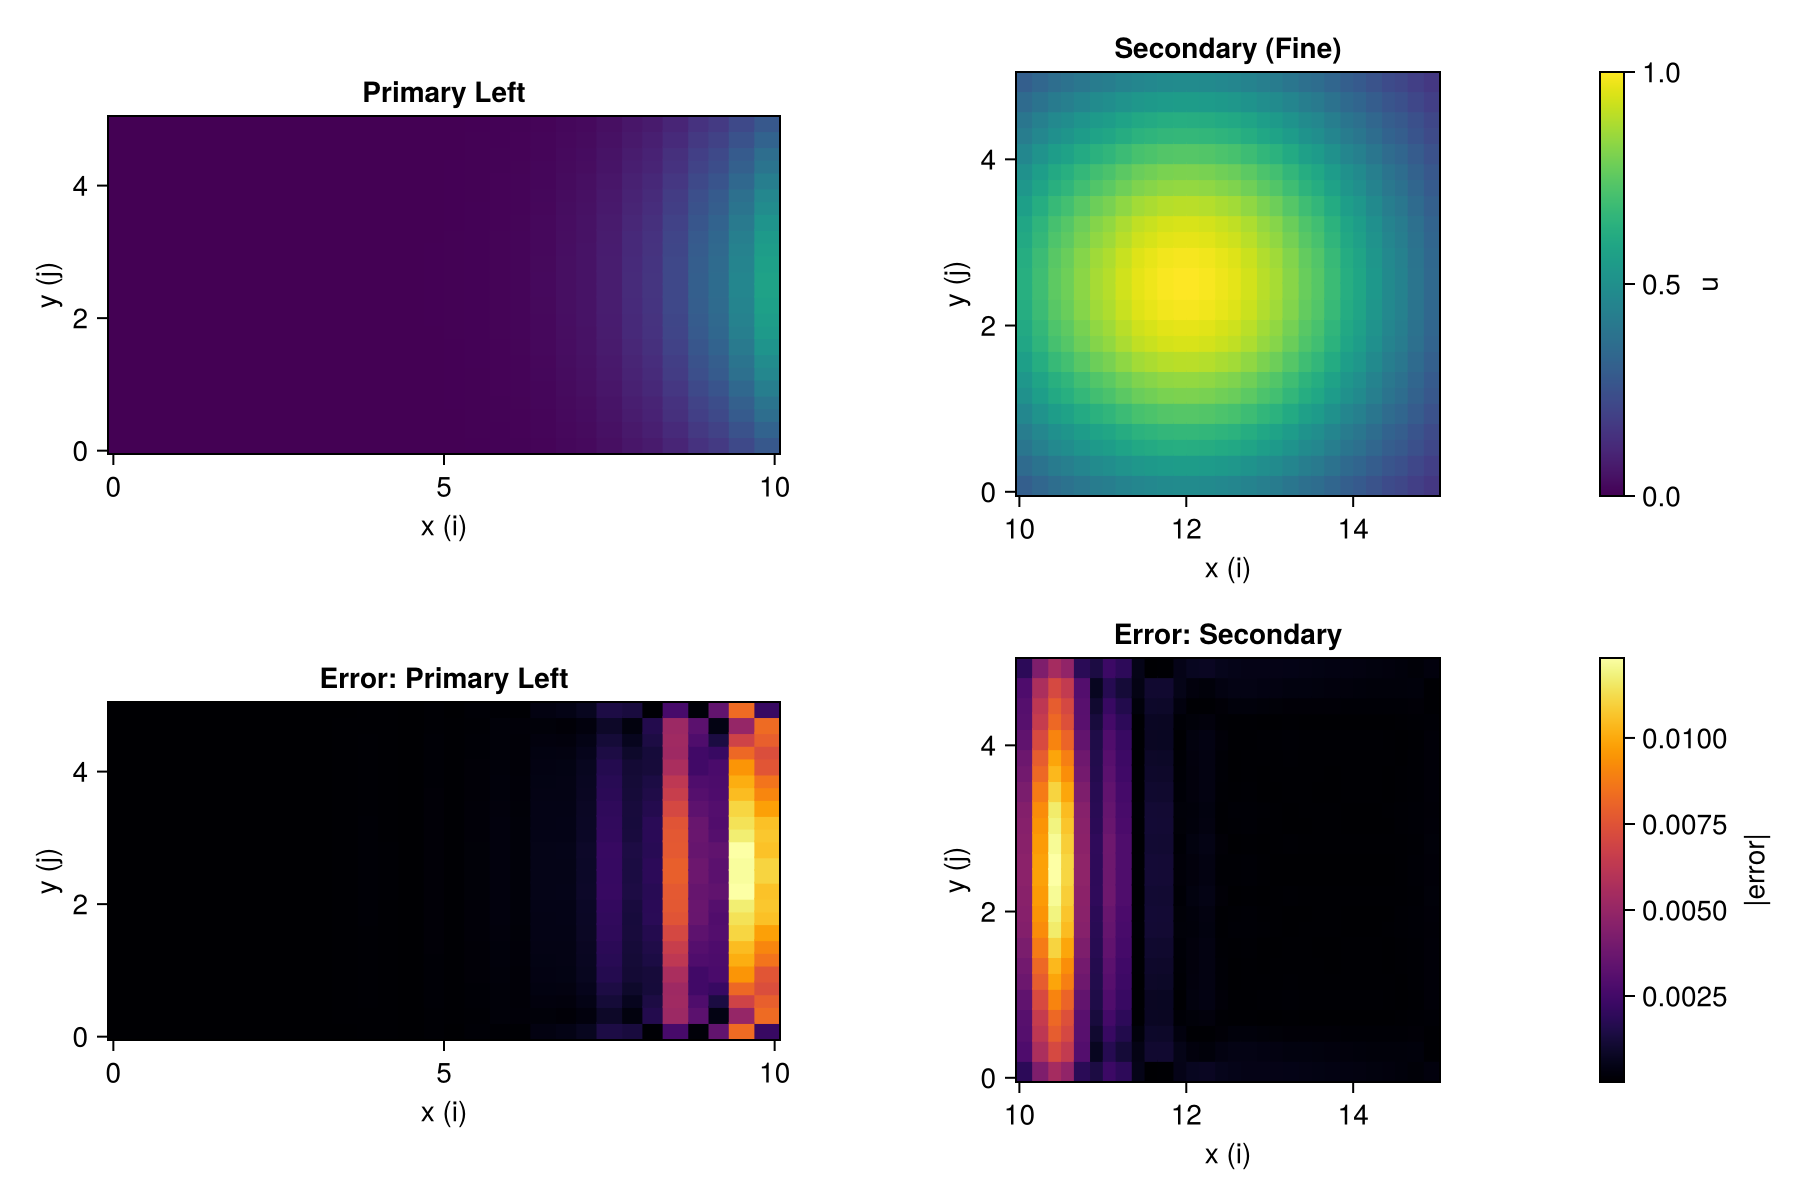

In [9]:
# Visualize 2D patches side by side
fig = Figure(size=(900, 600))

# Reshape physical data to 2D arrays (j varies fastest)
iDim_l = gp_2d_left.iDim
iDim_s = gp_2d_sec.iDim
pts_i_l = g2d_left.ibasis.data[1, 1].mishPoints
pts_j_l = g2d_left.jbasis.data[1, 1].mishPoints
pts_i_s = g2d_sec.ibasis.data[1, 1].mishPoints
pts_j_s = g2d_sec.jbasis.data[1, 1].mishPoints

u_left = reshape(g2d_left.physical[:, 1, 1], jDim, iDim_l)'
u_sec  = reshape(g2d_sec.physical[:, 1, 1], jDim, iDim_s)'

# Exact reference on combined domain
exact_left = [f_2d(pts_i_l[r], pts_j_l[l]) for r in 1:iDim_l, l in 1:jDim]
exact_sec  = [f_2d(pts_i_s[r], pts_j_s[l]) for r in 1:iDim_s, l in 1:jDim]

# Heatmap: reconstructed field
ax1 = Axis(fig[1, 1]; xlabel="x (i)", ylabel="y (j)", title="Primary Left", aspect=DataAspect())
hm1 = heatmap!(ax1, pts_i_l, pts_j_l, u_left; colormap=:viridis, colorrange=(0, 1))

ax2 = Axis(fig[1, 2]; xlabel="x (i)", ylabel="y (j)", title="Secondary (Fine)", aspect=DataAspect())
hm2 = heatmap!(ax2, pts_i_s, pts_j_s, u_sec; colormap=:viridis, colorrange=(0, 1))
Colorbar(fig[1, 3], hm2; label="u")

# Heatmap: error
err_left = abs.(u_left .- exact_left)
err_sec  = abs.(u_sec .- exact_sec)

ax3 = Axis(fig[2, 1]; xlabel="x (i)", ylabel="y (j)", title="Error: Primary Left", aspect=DataAspect())
hm3 = heatmap!(ax3, pts_i_l, pts_j_l, err_left; colormap=:inferno)

ax4 = Axis(fig[2, 2]; xlabel="x (i)", ylabel="y (j)", title="Error: Secondary", aspect=DataAspect())
hm4 = heatmap!(ax4, pts_i_s, pts_j_s, err_sec; colormap=:inferno)
Colorbar(fig[2, 3], hm4; label="|error|")

println("Primary left max error: $(maximum(err_left))")
println("Secondary max error:    $(maximum(err_sec))")

fig

## Example 6: 1:1 Domain Decomposition

With `COUPLING_MATRIX_1X` (identity), same-resolution patches can be connected for domain decomposition. The left grid is primary by convention. This enables parallelization across subdomains.

Single-grid max error: 2.156193968150255e-5
Decomposed max errors: 2.156193966607045e-5, 0.0004441620084870146, 0.0014076318563875923


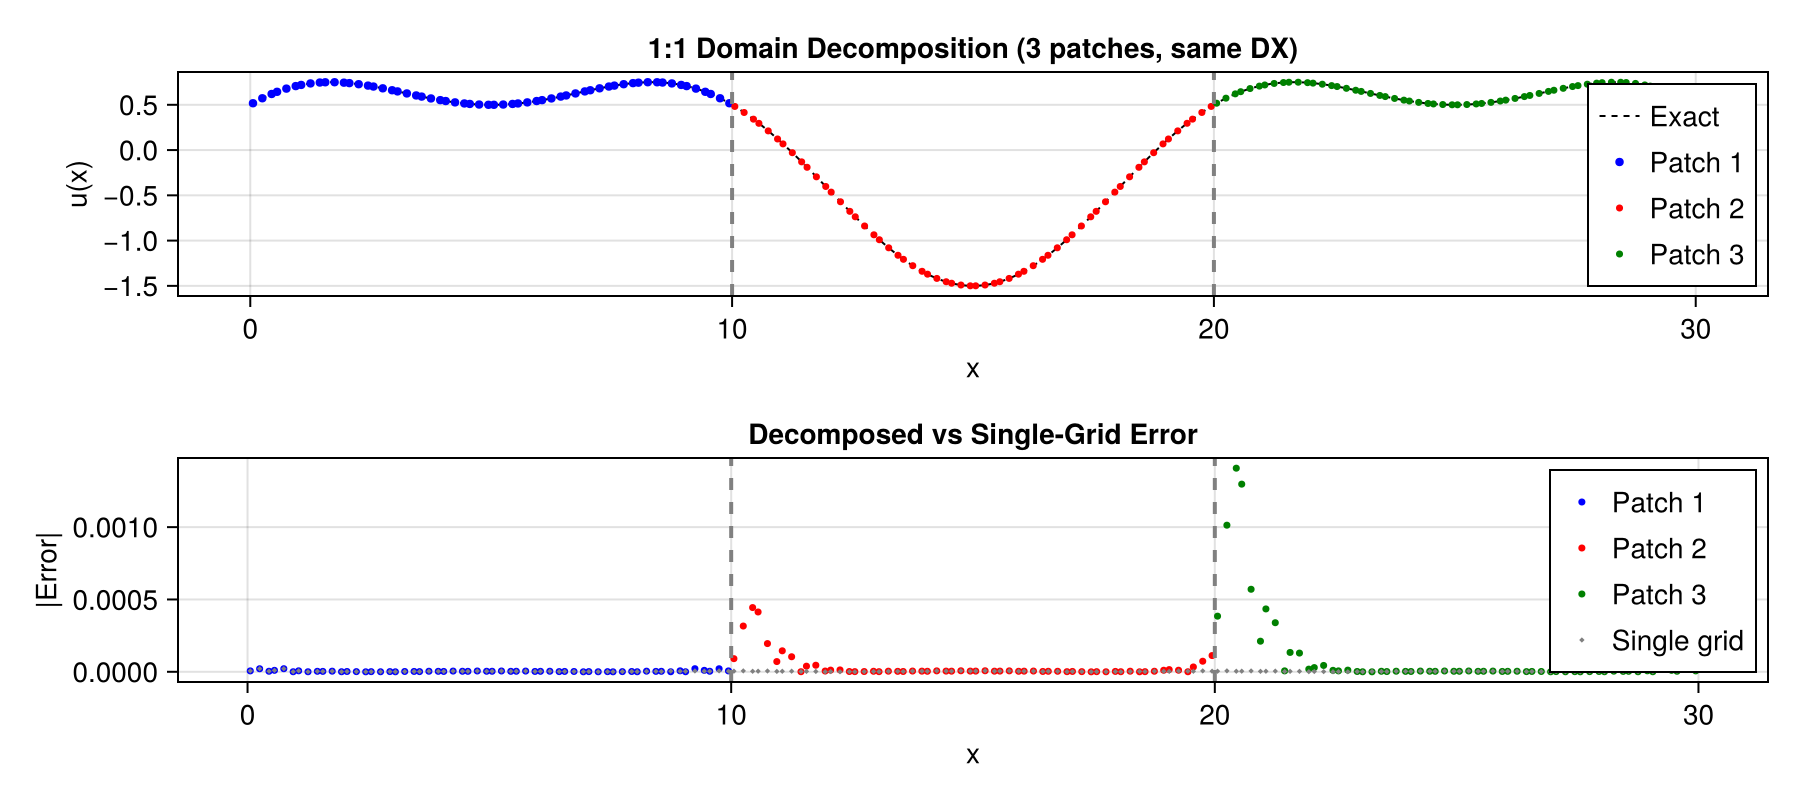

In [10]:
f_decomp(x) = sin(2π * x / 20.0) + 0.5 * cos(4π * x / 20.0)

# Three patches with identical resolution (DX = 0.5), splitting [0, 30]
gp_d1 = SpringsteelGridParameters(
    geometry="R", iMin=0.0, iMax=10.0, num_cells=20,
    BCL=Dict("u" => CubicBSpline.R0), BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))
gp_d2 = SpringsteelGridParameters(
    geometry="R", iMin=10.0, iMax=20.0, num_cells=20,
    BCL=Dict("u" => CubicBSpline.R3X), BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))
gp_d3 = SpringsteelGridParameters(
    geometry="R", iMin=20.0, iMax=30.0, num_cells=20,
    BCL=Dict("u" => CubicBSpline.R3X), BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

gd1 = createGrid(gp_d1); gd2 = createGrid(gp_d2); gd3 = createGrid(gp_d3)
for (g, pts) in [(gd1, getGridpoints(gd1)), (gd2, getGridpoints(gd2)), (gd3, getGridpoints(gd3))]
    for i in eachindex(pts); g.physical[i, 1, 1] = f_decomp(pts[i]); end
    spectralTransform!(g)
end

# PatchChain auto-detects 1:1 → left is primary at each interface
mpg_dd = PatchChain([gd1, gd2, gd3])
multiGridTransform!(mpg_dd)

# Compare to single-grid result
gp_full = SpringsteelGridParameters(
    geometry="R", iMin=0.0, iMax=30.0, num_cells=60,
    BCL=Dict("u" => CubicBSpline.R0), BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))
g_full = createGrid(gp_full)
pts_full = getGridpoints(g_full)
for i in eachindex(pts_full); g_full.physical[i, 1, 1] = f_decomp(pts_full[i]); end
spectralTransform!(g_full); gridTransform!(g_full)

fig = Figure(size=(900, 400))

ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="u(x)", title="1:1 Domain Decomposition (3 patches, same DX)")
x_ref = collect(range(0, 30, length=300))
lines!(ax1, x_ref, f_decomp.(x_ref); color=:black, linewidth=1, linestyle=:dash, label="Exact")
scatter!(ax1, getGridpoints(gd1), gd1.physical[:, 1, 1]; color=:blue, markersize=6, label="Patch 1")
scatter!(ax1, getGridpoints(gd2), gd2.physical[:, 1, 1]; color=:red, markersize=5, label="Patch 2")
scatter!(ax1, getGridpoints(gd3), gd3.physical[:, 1, 1]; color=:green, markersize=5, label="Patch 3")
vlines!(ax1, [10.0, 20.0]; color=:gray, linewidth=2, linestyle=:dash)
axislegend(ax1; position=:rt)

ax2 = Axis(fig[2, 1]; xlabel="x", ylabel="|Error|", title="Decomposed vs Single-Grid Error")
for (g, col, lbl) in [(gd1, :blue, "Patch 1"), (gd2, :red, "Patch 2"), (gd3, :green, "Patch 3")]
    pts = getGridpoints(g)
    err = abs.(g.physical[:, 1, 1] .- f_decomp.(pts))
    scatter!(ax2, pts, err; color=col, markersize=5, label=lbl)
end
err_full = abs.(g_full.physical[:, 1, 1] .- f_decomp.(pts_full))
scatter!(ax2, pts_full, err_full; color=:gray, markersize=3, marker=:diamond, label="Single grid")
vlines!(ax2, [10.0, 20.0]; color=:gray, linewidth=2, linestyle=:dash)
axislegend(ax2; position=:rt)

println("Single-grid max error: $(maximum(err_full))")
println("Decomposed max errors: $(maximum(abs.(gd1.physical[:,1,1] .- f_decomp.(getGridpoints(gd1))))), " *
        "$(maximum(abs.(gd2.physical[:,1,1] .- f_decomp.(getGridpoints(gd2))))), " *
        "$(maximum(abs.(gd3.physical[:,1,1] .- f_decomp.(getGridpoints(gd3)))))")

fig

## Example 7: 5-Patch Refinement Chain (4-2-1-2-4 DX)

A deeper chain with progressive 2:1 refinement toward the center. `PatchChain` automatically determines that the coarser grid is primary at each interface, and the topological sort produces 3 layers (DX=4 first, then DX=2, then DX=1).

In [18]:
f_chain(x) = exp(-((x - 50)^2) / 200.0) * sin(2π * x / 20.0)
lq_0 = Dict("u" => 0.0)

# 5-patch chain: DX = 4, 2, 1, 2, 4
# Domain: [0,40] [40,60] [60,70] [70,90] [90,130]
# BCs: outer R0, interface sides alternate R0 (primary) / R3X (secondary)
configs = [
    # (iMin, iMax, num_cells, BCL, BCR)
    (0.0,   40.0, 40, CubicBSpline.R0,  CubicBSpline.R0),   # DX=4, primary both sides
    (40.0,  60.0, 40, CubicBSpline.R3X, CubicBSpline.R0),   # DX=2, secondary left, primary right
    (60.0,  70.0, 40, CubicBSpline.R3X, CubicBSpline.R3X),  # DX=1, secondary both sides
    (70.0,  90.0, 40, CubicBSpline.R0,  CubicBSpline.R3X),  # DX=2, primary left, secondary right
    (90.0, 130.0, 40, CubicBSpline.R0,  CubicBSpline.R0),   # DX=4, primary both sides
]

chain_grids = SpringsteelGrid[]
for (imin, imax, nc, bcl, bcr) in configs
    gp = SpringsteelGridParameters(
        geometry="R", iMin=imin, iMax=imax, num_cells=nc, l_q=lq_0,
        BCL=Dict("u" => bcl), BCR=Dict("u" => bcr),
        vars=Dict("u" => 1))
    push!(chain_grids, createGrid(gp))
end

for g in chain_grids
    pts = getGridpoints(g)
    for i in eachindex(pts); g.physical[i, 1, 1] = f_chain(pts[i]); end
    spectralTransform!(g)
end

mpg_chain = PatchChain(chain_grids)
multiGridTransform!(mpg_chain)

println("5-patch chain: $(length(mpg_chain.interfaces)) interfaces, $(length(mpg_chain.transform_order)) layers")
println("Transform order: $(mpg_chain.transform_order)")
println("DX per patch: $([(g.params.iMax - g.params.iMin) / g.params.num_cells for g in chain_grids])")

5-patch chain: 4 interfaces, 3 layers
Transform order: [[1, 5], [2, 4], [3]]
DX per patch: [1.0, 0.5, 0.25, 0.5, 1.0]


Patch 1 (DX=4): max error = 1.483886925762734e-5
Patch 2 (DX=2): max error = 7.654186243080674e-5
Patch 3 (DX=1): max error = 4.904164178753945e-6
Patch 4 (DX=2): max error = 2.2317790316153663e-7
Patch 5 (DX=4): max error = 1.4300908150559604e-8


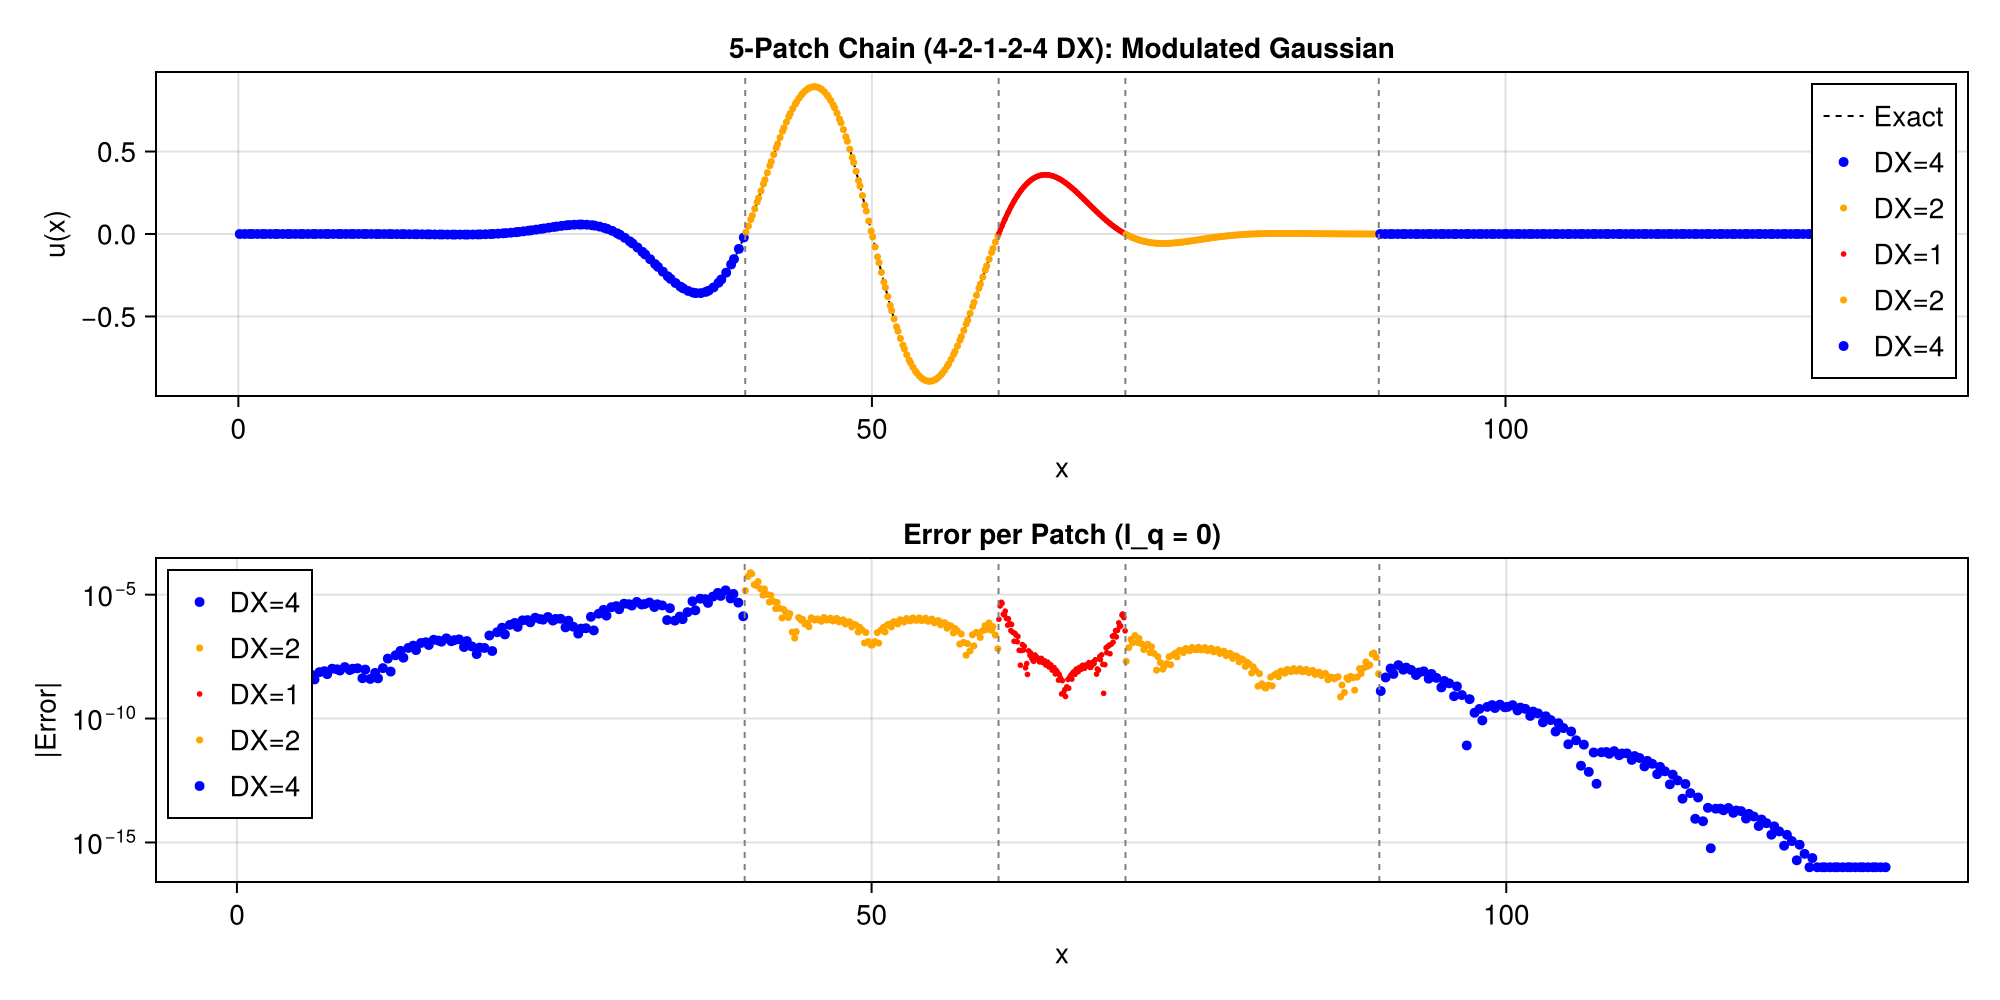

In [19]:
# Visualize the 5-patch chain
fig = Figure(size=(1000, 500))

colors = [:blue, :orange, :red, :orange, :blue]
labels = ["DX=4", "DX=2", "DX=1", "DX=2", "DX=4"]
boundaries = [40.0, 60.0, 70.0, 90.0]

ax1 = Axis(fig[1, 1]; xlabel="x", ylabel="u(x)",
           title="5-Patch Chain (4-2-1-2-4 DX): Modulated Gaussian")
x_ref = collect(range(0, 130, length=500))
lines!(ax1, x_ref, f_chain.(x_ref); color=:black, linewidth=1, linestyle=:dash, label="Exact")
for (k, g) in enumerate(chain_grids)
    pts = getGridpoints(g)
    ms = k == 3 ? 4 : (k in (2,4) ? 5 : 7)
    scatter!(ax1, pts, g.physical[:, 1, 1]; color=colors[k], markersize=ms, label=labels[k])
end
vlines!(ax1, boundaries; color=:gray, linewidth=1, linestyle=:dash)
axislegend(ax1; position=:rt)

# Error on log scale
ax2 = Axis(fig[2, 1]; xlabel="x", ylabel="|Error|",
           title="Error per Patch (l_q = 0)", yscale=log10)
for (k, g) in enumerate(chain_grids)
    pts = getGridpoints(g)
    err = abs.(g.physical[:, 1, 1] .- f_chain.(pts))
    err[err .< 1e-16] .= 1e-16
    ms = k == 3 ? 4 : (k in (2,4) ? 5 : 7)
    scatter!(ax2, pts, err; color=colors[k], markersize=ms, label=labels[k])
    println("Patch $k ($(labels[k])): max error = $(maximum(abs.(g.physical[:, 1, 1] .- f_chain.(pts))))")
end
vlines!(ax2, boundaries; color=:gray, linewidth=1, linestyle=:dash)
axislegend(ax2; position=:lt)

fig

## Example 8: Independent Transform for Time-Stepping

In numerical modeling, the primary grid may evolve at a different cadence than the fine grid. The `update_interface!` function can be called independently between separate `gridTransform!` calls, supporting flexible time-stepping strategies.

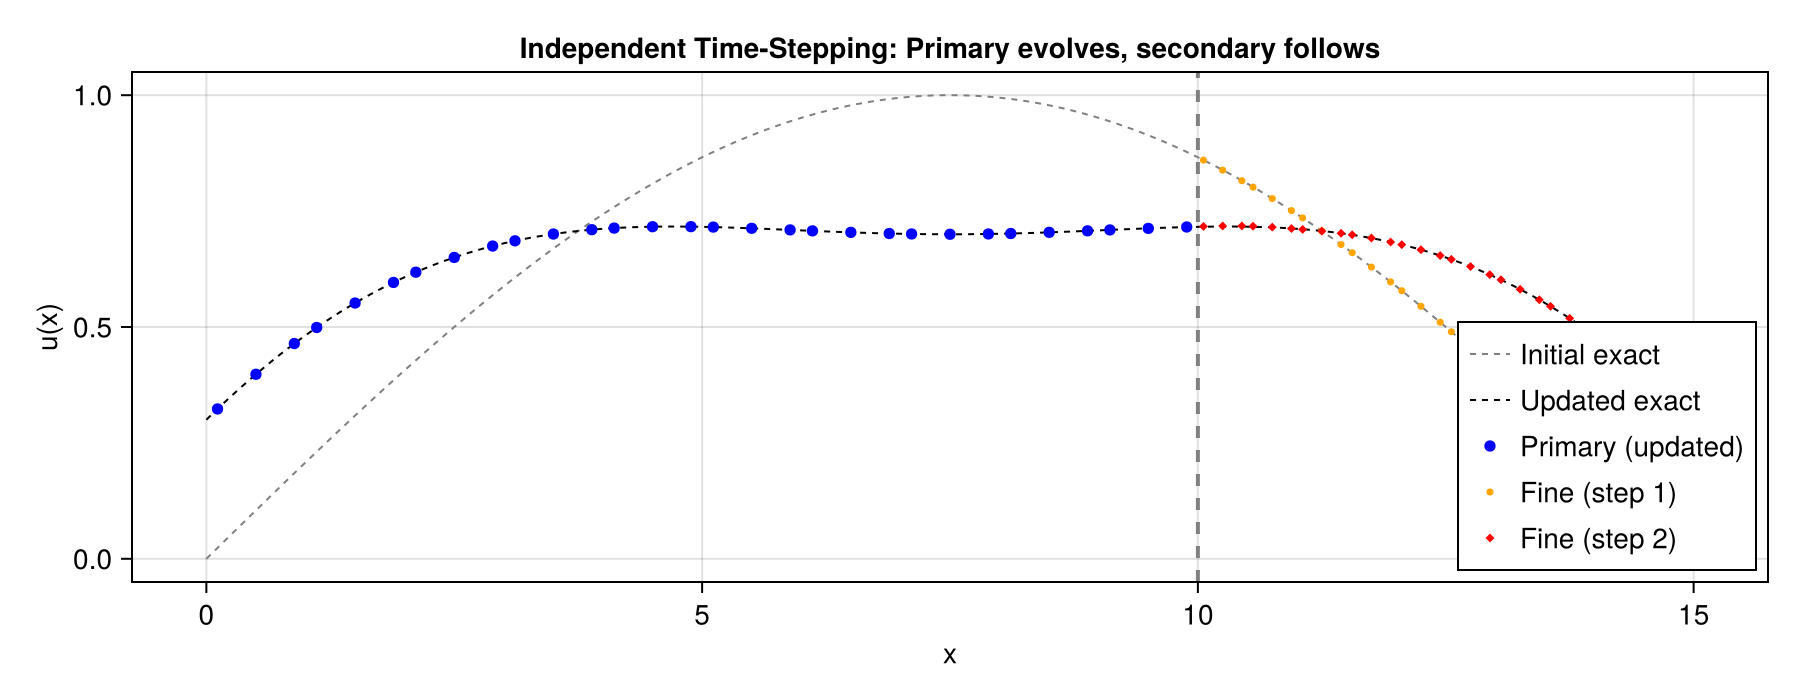

In [13]:
# Simulate a simple advection-like scenario:
# Primary grid is updated once, secondary is updated multiple times

f_initial(x) = sin(2π * x / 30.0)
f_updated(x) = sin(2π * x / 30.0) + 0.3 * cos(4π * x / 30.0)  # Primary "evolves"

# Create grids
gp_pri = SpringsteelGridParameters(
    geometry="R", iMin=0.0, iMax=10.0, num_cells=10,
    BCL=Dict("u" => CubicBSpline.R0), BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))
gp_fin = SpringsteelGridParameters(
    geometry="R", iMin=10.0, iMax=15.0, num_cells=10,
    BCL=Dict("u" => CubicBSpline.R3X), BCR=Dict("u" => CubicBSpline.R0),
    vars=Dict("u" => 1))

g_pri = createGrid(gp_pri)
g_fin = createGrid(gp_fin)
iface = PatchInterface(g_pri, g_fin, :right, :left, :i)

# Step 1: initial state on primary
pts_p = getGridpoints(g_pri)
pts_f = getGridpoints(g_fin)
for i in eachindex(pts_p); g_pri.physical[i, 1, 1] = f_initial(pts_p[i]); end
spectralTransform!(g_pri)
gridTransform!(g_pri)

# Transfer initial BCs to fine grid
for i in eachindex(pts_f); g_fin.physical[i, 1, 1] = f_initial(pts_f[i]); end
spectralTransform!(g_fin)
update_interface!(iface)
gridTransform!(g_fin)

u_fine_step1 = copy(g_fin.physical[:, 1, 1])

# Step 2: primary evolves, update interface, transform fine grid again
for i in eachindex(pts_p); g_pri.physical[i, 1, 1] = f_updated(pts_p[i]); end
spectralTransform!(g_pri)
gridTransform!(g_pri)

# Fine grid keeps its own data but gets updated boundary from primary
for i in eachindex(pts_f); g_fin.physical[i, 1, 1] = f_updated(pts_f[i]); end
spectralTransform!(g_fin)
update_interface!(iface)  # Updated BCs from evolved primary
gridTransform!(g_fin)

u_fine_step2 = copy(g_fin.physical[:, 1, 1])

# Visualize the two steps
fig = Figure(size=(900, 350))
ax = Axis(fig[1, 1]; xlabel="x", ylabel="u(x)",
          title="Independent Time-Stepping: Primary evolves, secondary follows")

x_all = collect(range(0, 15, length=200))
lines!(ax, x_all, f_initial.(x_all); color=:gray, linewidth=1, linestyle=:dash, label="Initial exact")
lines!(ax, x_all, f_updated.(x_all); color=:black, linewidth=1, linestyle=:dash, label="Updated exact")

scatter!(ax, pts_p, g_pri.physical[:, 1, 1]; color=:blue, markersize=8, label="Primary (updated)")
scatter!(ax, pts_f, u_fine_step1; color=:orange, markersize=5, label="Fine (step 1)")
scatter!(ax, pts_f, u_fine_step2; color=:red, markersize=5, marker=:diamond, label="Fine (step 2)")
vlines!(ax, [10.0]; color=:gray, linewidth=2, linestyle=:dash)
axislegend(ax; position=:rb)

fig

## Summary

| Feature | Status |
|---------|--------|
| `PatchChain` — end-to-end grid chains | Supported (1:1 and 2:1 ratios) |
| `PatchEmbedded` — nested grids | Supported (2:1 ratio, multi-level) |
| 1:1 domain decomposition | Supported via `PatchChain` |
| Asymmetric chains (e.g., 4-2-1-2-4) | Supported (auto-detects primary) |
| 2D i-dimension interface (RR grids) | Supported |
| 2D j-dimension interface | Deferred (requires split RR transform) |
| k-dimension connections | Deferred |
| Fourier/Chebyshev patching | Not applicable (CubicBSpline only) |
| Independent time-stepping | Supported via manual `gridTransform!` + `update_interface!` |
| Coupled transform | `multiGridTransform!` with automatic topological ordering |

**Key considerations:**
- The 3x3 coupling matrix is exact for unsmoothed B-spline amplitudes
- The `l_q` smoothing parameter on the **primary** (coarser) grid controls coupling accuracy; secondary `l_q` is irrelevant for polynomials
- Grids must have 2:1 or 1:1 cell-width ratio and be nodally aligned
- Primary patches use R0 (free) BCs at interfaces; secondary patches use R3X
- For chains, patches forwarding BCs should use `l_q=0` to prevent error amplification downstream